# IMU-Based Device for Powerlifting Insights
## Pilot Trial — Exploratory Data Analysis

---

### Session Metadata

| Field | Value |
|---|---|
| Date | April 9, 2026 |
| Exercise | Bench Press |
| Load | 45 lbs (bar only) |
| Reps | 10 |
| Duration | ~43.4 s |
| Sample Rate | 200 Hz |
| Samples | 8,683 |
| File | `session_20260409_175030.csv` |

---

### Project Background

This project builds an open-source, barbell-mounted IMU system for automated powerlifting analysis — targeting the squat, bench press, and deadlift. Commercial velocity-based training (VBT) devices cost $200–400 and are closed-source. Our device costs ~$96 using off-the-shelf components and is fully reproducible.

**Three core hypotheses:**
1. A neural network trained on windowed IMU time-series can count reps with **>95% accuracy**
2. An Extended Kalman Filter (EKF) fusing accel + gyro can reconstruct bar path trajectories matching OpenCap ground truth
3. IMU-derived velocity can predict 1RM within **5% of actual**, outperforming Epley/Brzycki formulas

---

### Hardware

Data is logged at **200 Hz** to MicroSD as CSV with columns: `timestamp_ms`, `a1x`, `a1y`, `a1z`, `g1x`, `g1y`, `g1z` — linear acceleration (m/s²) and angular velocity (rad/s) from IMU 1.

---

### What This Notebook Covers

```
1. Setup & Data Loading       — import raw CSV, inspect shape and signal ranges
2. Signal Visualization       — raw accelerometer and gyroscope traces
3. Preprocessing              — low-pass filtering (Butterworth, 15 Hz cutoff)
4. Gravity Compensation       — calibration-period subtraction of static gravity
5. Velocity Estimation        — integration with ZUPT (zero-velocity updates) + drift correction
6. Bar Path Reconstruction    — double integration → 2D trajectory per rep
7. Rep Detection              — zero-crossing + peak detection on vertical velocity
8. Per-Rep Metrics            — mean/peak concentric velocity, ROM, time-to-peak-v
9. Fatigue & RPE Estimation   — velocity loss %, Helms-style RPE mapping
10. 1RM Projection            — single-point load-velocity estimate (Jidovtseff 2011)
```

> **Note:** This is a pilot trial at 45 lbs (well below working loads). Velocity-based 1RM estimates are less reliable at very light loads — accuracy improves as load approaches ~70%+ of 1RM. The primary goal here is validating the signal processing pipeline and rep detection logic.

---
## 1. Setup & Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt, find_peaks
from scipy.integrate import cumulative_trapezoid

# ── Session config ──────────────────────────────────────────────────
CSV_PATH    = "../data_collection/session_20260409_175030.csv"
EXERCISE    = "Bench Press"
LOAD_LBS    = 45.0
SAMPLE_RATE = 200        # Hz
GRAVITY     = 9.81       # m/s²
LP_CUTOFF   = 15.0       # Hz — low-pass for accel/gyro smoothing
HP_CUTOFF   = 0.3        # Hz — high-pass to remove velocity drift
MVT         = 0.17       # m/s — minimum velocity threshold for bench press

# ── Load data ───────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
t_ms = df["timestamp_ms"].values.astype(float)
t_s  = t_ms / 1000.0
dt   = 1.0 / SAMPLE_RATE

print(f"Loaded: {len(df):,} samples  |  {t_s[-1]:.1f}s duration  |  {SAMPLE_RATE} Hz")
print(f"Columns: {list(df.columns)}")
print()
df.head(10)

Loaded: 8,683 samples  |  43.4s duration  |  200 Hz
Columns: ['timestamp_ms', 'a1x', 'a1y', 'a1z', 'g1x', 'g1y', 'g1z']



,timestamp_ms,a1x,a1y,a1z,g1x,g1y,g1z
0,5,0.172,9.672,1.287,0.0110,0.0061,0.0012
1,10,0.163,9.638,1.297,0.0110,0.0061,0.0012
2,15,0.163,9.653,1.287,0.0122,0.0061,0.0000
3,20,0.187,9.667,1.273,0.0134,0.0049,0.0012
4,25,0.206,9.657,1.263,0.0122,0.0049,0.0000
5,30,0.177,9.634,1.273,0.0122,0.0061,0.0012
6,35,0.196,9.643,1.297,0.0122,0.0049,0.0012
7,40,0.182,9.653,1.302,0.0122,0.0061,0.0000
8,45,0.177,9.653,1.278,0.0122,0.0073,0.0000
9,50,0.172,9.672,1.306,0.0147,0.0049,0.0012


In [3]:
# Quick signal statistics
stats = df.drop(columns="timestamp_ms").describe().T
stats.columns = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
stats["range"] = stats["max"] - stats["min"]
print("Signal statistics:")
stats.round(4)

Signal statistics:


,count,mean,std,min,25%,50%,75%,max,range
a1x,8683.0,-0.5464,2.4863,-84.5240,-1.1050,-0.2870,0.1630,80.4510,164.9750
a1y,8683.0,9.6333,2.6059,-58.2170,9.3180,9.6530,9.9970,111.8170,170.0340
a1z,8683.0,1.2084,0.6519,-28.4890,1.0720,1.2630,1.3110,18.9270,47.4160
g1x,8683.0,0.0134,0.0845,-2.6756,-0.0049,0.0134,0.0354,2.1869,4.8625
g1y,8683.0,0.0063,0.0683,-2.0892,-0.0073,0.0061,0.0257,1.4111,3.5003
g1z,8683.0,0.0002,0.2294,-2.4691,-0.0831,0.0012,0.0794,2.0036,4.4727


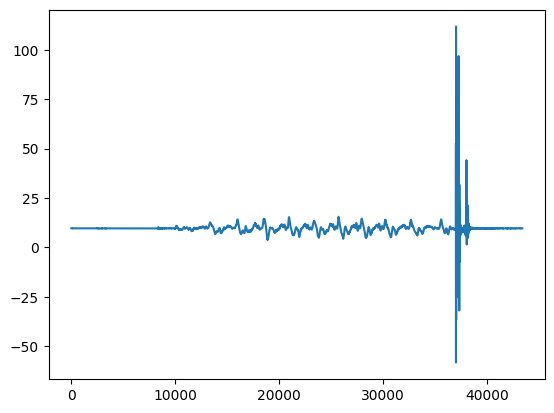

In [11]:
# Plot -a1x and a1y here
a1x = df['a1x']
a1y = df['a1y']
t = df['timestamp_ms']
plot = plt.plot(t, a1y)

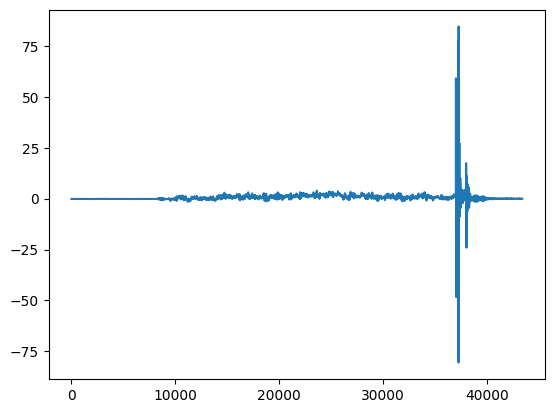

In [9]:
plot = plt.plot(t, -a1x)

---
## 2. Signal Preprocessing — Low-Pass Filter

A **4th-order zero-phase Butterworth** filter at **15 Hz** is applied to both acceleration axes before integration.

**Why 15 Hz for bench press?**
- Rep cadence is ~0.3–1 Hz; all meaningful bar-motion harmonics sit below ~5 Hz
- Impact transients and vibration from the bar/clips live above 20 Hz
- 15 Hz preserves the full movement signal while suppressing high-frequency noise that would accumulate into large drift after integration
- `filtfilt` is used for **zero-phase** filtering — no temporal shift in the signal

In [ ]:
# ── Butterworth low-pass filter ─────────────────────────────────────
nyq = SAMPLE_RATE / 2.0
b_lp, a_lp = butter(4, LP_CUTOFF / nyq, btype="low")

a1x_raw = df["a1x"].values
a1y_raw = df["a1y"].values

a1x_filt = filtfilt(b_lp, a_lp, a1x_raw)
a1y_filt = filtfilt(b_lp, a_lp, a1y_raw)

# ── Raw vs filtered comparison ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f"Accelerometer: Raw vs Low-Pass Filtered ({LP_CUTOFF} Hz, 4th-order Butterworth)", fontsize=13)

axes[0].plot(t_s, a1y_raw,  color="lightsteelblue", lw=0.7, alpha=0.8, label="raw a1y")
axes[0].plot(t_s, a1y_filt, color="steelblue",      lw=1.4, label=f"filtered a1y ({LP_CUTOFF} Hz)")
axes[0].set_ylabel("a1y  (m/s²)")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].grid(True, lw=0.4)

axes[1].plot(t_s, -a1x_raw,  color="lightsalmon", lw=0.7, alpha=0.8, label="raw −a1x")
axes[1].plot(t_s, -a1x_filt, color="tomato",      lw=1.4, label=f"filtered −a1x ({LP_CUTOFF} Hz)")
axes[1].set_ylabel("−a1x  (m/s²)")
axes[1].set_xlabel("Time (s)")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(True, lw=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# Integrate filtered acceleration → velocity
vy = cumulative_trapezoid(a1y_filt, dx=dt, initial=0)
vx = cumulative_trapezoid(a1x_filt, dx=dt, initial=0)

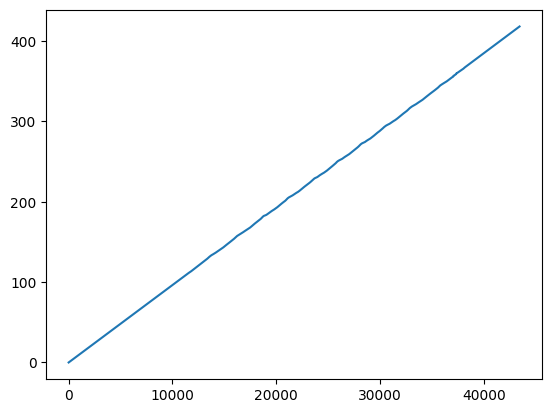

In [16]:
plot = plt.plot(t, vy)

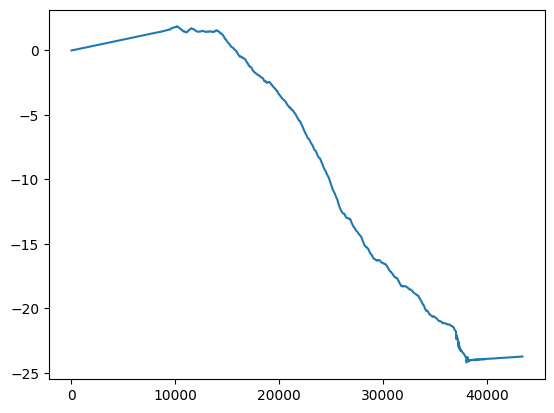

In [17]:
plot = plt.plot(t, vx)